In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from statsbombpy import sb
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrow

In [2]:
competitions = sb.competitions()

competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [3]:
competitions.columns.tolist()

['competition_id',
 'season_id',
 'country_name',
 'competition_name',
 'competition_gender',
 'competition_youth',
 'competition_international',
 'season_name',
 'match_updated',
 'match_updated_360',
 'match_available_360',
 'match_available']

In [4]:
competitions_view = competitions[
    [
        "competition_id",
        "season_id",
        "country_name",
        "competition_name",
        "competition_gender",
        "season_name",
        "match_available"
    ]
].sort_values(
    by=["competition_name", "season_name"]
)

competitions_view.head(50)

,competition_id,season_id,country_name,competition_name,competition_gender,season_name,match_available
1,9,27,Germany,1. Bundesliga,male,2015/2016,2024-05-19T11:11:14.192381
0,9,281,Germany,1. Bundesliga,male,2023/2024,2024-09-28T20:46:38.893391
2,1267,107,Africa,African Cup of Nations,male,2023,2024-09-28T01:57:35.846538
20,16,276,Europe,Champions League,male,1970/1971,2024-02-13T14:24:12.213582
19,16,71,Europe,Champions League,male,1971/1972,2024-02-12T14:25:01.735880
18,16,277,Europe,Champions League,male,1972/1973,2024-02-13T14:25:16.532771
17,16,76,Europe,Champions League,male,1999/2000,2025-06-23T12:34:36.649637
16,16,44,Europe,Champions League,male,2003/2004,2025-06-24T13:57:37.321382
15,16,37,Europe,Champions League,male,2004/2005,2025-06-24T09:44:09.039471
14,16,39,Europe,Champions League,male,2006/2007,2024-02-12T13:48:23.967222


In [5]:
male_competitions = competitions[
    competitions["competition_gender"] == "male"
].copy()

male_competitions[
    [
        "competition_id",
        "season_id",
        "country_name",
        "competition_name",
        "season_name",
        "match_available"
    ]
].sort_values(
    by=["country_name", "competition_name", "season_name"]
).reset_index(drop=True)

,competition_id,season_id,country_name,competition_name,season_name,match_available
0,1267,107,Africa,African Cup of Nations,2023,2024-09-28T01:57:35.846538
1,81,275,Argentina,Liga Profesional,1981,2023-12-05T14:19:40.272816
2,81,48,Argentina,Liga Profesional,1997/1998,2023-06-28T11:19:54.593488
3,2,44,England,Premier League,2003/2004,2025-06-24T13:53:07.585114
4,2,27,England,Premier League,2015/2016,2025-04-23T14:36:29.347042
...,...,...,...,...,...,...
62,11,1,Spain,La Liga,2017/2018,2025-07-14T10:01:16.674864
63,11,4,Spain,La Liga,2018/2019,2024-09-22T18:50:23.364757
64,11,42,Spain,La Liga,2019/2020,2024-12-16T16:51:06.833054
65,11,90,Spain,La Liga,2020/2021,2025-01-29T17:39:28.924386


In [6]:
# Project parameters

COMPETITION_ID = 55
SEASON_ID = 282

In [7]:
matches = sb.matches(
    competition_id=COMPETITION_ID,
    season_id=SEASON_ID
)

matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,1,2,available,available,2024-07-15T07:54:23.583297,2024-07-15T07:57:36.684453,6,...,Netherlands,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,...,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,...,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,2,1,available,available,2024-07-10T06:50:04.068615,2024-07-10T06:56:35.146850,5,...,Netherlands,232,Vincenzo Montella,NaN,1974-06-18,112,Italy,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,0,0,available,available,2024-07-12T01:57:15.210934,2024-07-12T02:00:16.871522,5,...,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2


In [8]:
matches_view = matches[
    [
        "match_id",
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "competition_stage"
    ]
].sort_values("match_date")

matches_view.reset_index(drop=True)

,match_id,match_date,home_team,away_team,home_score,away_score,competition_stage
0,3930158,2024-06-14,Germany,Scotland,5,1,Group Stage
1,3930160,2024-06-15,Spain,Croatia,3,0,Group Stage
2,3930161,2024-06-15,Italy,Albania,2,1,Group Stage
3,3930159,2024-06-15,Hungary,Switzerland,1,3,Group Stage
4,3930162,2024-06-16,Slovenia,Denmark,1,1,Group Stage
5,3930163,2024-06-16,Serbia,England,0,1,Group Stage
6,3938637,2024-06-16,Poland,Netherlands,1,2,Group Stage
7,3938638,2024-06-17,Romania,Ukraine,3,0,Group Stage
8,3930164,2024-06-17,Belgium,Slovakia,0,1,Group Stage
9,3930165,2024-06-17,Austria,France,0,1,Group Stage


In [10]:
MATCH_ID = 3943043

In [11]:
selected_match = matches[matches["match_id"] == MATCH_ID].iloc[0]

MATCH_DATE = selected_match["match_date"]
HOME_TEAM = selected_match["home_team"]
AWAY_TEAM = selected_match["away_team"]
HOME_SCORE = selected_match["home_score"]
AWAY_SCORE = selected_match["away_score"]
COMPETITION_STAGE = selected_match["competition_stage"]

MATCH_LABEL = f"{HOME_TEAM} {HOME_SCORE} - {AWAY_SCORE} {AWAY_TEAM}"

MATCH_LABEL, MATCH_DATE, COMPETITION_STAGE

('Spain 2 - 1 England', '2024-07-14', 'Final')

In [12]:
events = sb.events(match_id=MATCH_ID)

events.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [13]:
events.shape

(3312, 92)

In [14]:
events["type"].value_counts().head(20)

type
Pass               917
Ball Receipt*      878
Carry              759
Pressure           327
Ball Recovery       71
Duel                70
Block               43
Clearance           43
Goal Keeper         30
Shot                25
Dribble             24
Dispossessed        23
Foul Committed      19
Foul Won            19
Miscontrol          12
Dribbled Past       10
Interception         7
Substitution         7
Injury Stoppage      6
Half Start           4
Name: count, dtype: int64

In [15]:
passes = events[events["type"] == "Pass"].copy()

passes.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.340,Pass,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:04.742,Pass,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:34.440,Pass,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:36.279,Pass,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:39.436,Pass,NaN


In [16]:
len(passes)

917

In [17]:
passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "location",
        "pass_end_location",
        "pass_outcome",
        "pass_length",
        "pass_angle",
        "pass_height",
        "pass_recipient"
    ]
].head()

,team,player,position,minute,second,location,pass_end_location,pass_outcome,pass_length,pass_angle,pass_height,pass_recipient
6,England,Kobbie Mainoo,Right Defensive Midfield,0,0,"[60.0, 40.0]","[25.4, 38.8]",NaN,34.620804,-3.106924,Ground Pass,Jordan Pickford
7,England,Jordan Pickford,Goalkeeper,0,4,"[28.7, 31.6]","[120.0, 67.7]",Out,98.177900,0.376534,High Pass,Bukayo Saka
8,Spain,Unai Simón Mendibil,Goalkeeper,0,34,"[6.9, 39.6]","[9.1, 57.2]",NaN,17.736967,1.446441,Ground Pass,Robin Aime Robert Le Normand
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,"[8.9, 57.2]","[20.6, 75.8]",NaN,21.973848,1.009303,Ground Pass,Daniel Carvajal Ramos
10,Spain,Daniel Carvajal Ramos,Right Back,0,39,"[28.6, 76.4]","[50.2, 68.5]",NaN,22.999348,-0.350628,Ground Pass,Daniel Olmo Carvajal


In [18]:
players_positions = events[
    ["team", "player", "position"]
].dropna().drop_duplicates()

players_positions = players_positions.sort_values(
    by=["team", "position", "player"]
)

players_positions.head(50)

,team,player,position
733,England,Cole Palmer,Center Attacking Midfield
43,England,Phil Foden,Center Attacking Midfield
918,England,Declan Rice,Center Defensive Midfield
63,England,Harry Kane,Center Forward
902,England,Ollie Watkins,Center Forward
7,England,Jordan Pickford,Goalkeeper
21,England,Luke Shaw,Left Back
28,England,Marc Guehi,Left Center Back
1791,England,Ivan Toney,Left Center Forward
22,England,Declan Rice,Left Defensive Midfield


In [19]:
centre_backs = players_positions[
    players_positions["position"].str.contains("Center Back", case=False, na=False)
].copy()

centre_backs

,team,player,position
28,England,Marc Guehi,Left Center Back
120,England,John Stones,Right Center Back
18,Spain,Aymeric Laporte,Left Center Back
864,Spain,José Ignacio Fernández Iglesias,Right Center Back
9,Spain,Robin Aime Robert Le Normand,Right Center Back


In [20]:
cb_passes = passes.merge(
    centre_backs,
    on=["team", "player", "position"],
    how="inner"
)

cb_pass_counts = (
    cb_passes
    .groupby(["team", "player", "position"])
    .size()
    .reset_index(name="pass_count")
    .sort_values("pass_count", ascending=False)
)

cb_pass_counts

,team,player,position,pass_count
4,Spain,Robin Aime Robert Le Normand,Right Center Back,84
2,Spain,Aymeric Laporte,Left Center Back,83
0,England,John Stones,Right Center Back,35
1,England,Marc Guehi,Left Center Back,26
3,Spain,José Ignacio Fernández Iglesias,Right Center Back,3


In [21]:
PLAYER_NAME = "Robin Aime Robert Le Normand"

In [22]:
player_passes = passes[passes["player"] == PLAYER_NAME].copy()

player_passes.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:36.279,Pass,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:01:08.606,Pass,NaN
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:01:22.894,Pass,NaN
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:01:50.034,Pass,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:02:21.003,Pass,True


In [23]:
len(player_passes)

84

In [24]:
TEAM_NAME = player_passes["team"].mode()[0]
POSITION_NAME = player_passes["position"].mode()[0]

TEAM_NAME, POSITION_NAME

('Spain', 'Right Center Back')

In [26]:
def extract_coordinate(value, index):
    if isinstance(value, list) and len(value) > index:
        return value[index]
    return np.nan

In [27]:
player_passes["x"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["y"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 1)
)

player_passes["end_x"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["end_y"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 1)
)

In [28]:
player_passes["is_completed"] = player_passes["pass_outcome"].isna()

In [29]:
player_passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_outcome",
        "is_completed"
    ]
].head()

,team,player,position,minute,second,x,y,end_x,end_y,pass_outcome,is_completed
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,8.9,57.2,20.6,75.8,NaN,True
17,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,23.3,60.1,27.4,33.8,NaN,True
19,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,42.9,54.1,43.5,25.2,NaN,True
25,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,29.0,67.8,34.9,76.0,NaN,True
30,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,29.2,64.7,3.8,45.5,NaN,True


In [30]:
player_passes[["x", "y", "end_x", "end_y"]].isna().sum()

x        0
y        0
end_x    0
end_y    0
dtype: int64

In [31]:
player_passes["x_progression"] = player_passes["end_x"] - player_passes["x"]
player_passes["y_progression"] = player_passes["end_y"] - player_passes["y"]

player_passes["is_forward_pass"] = player_passes["x_progression"] > 0
player_passes["is_long_pass"] = player_passes["pass_length"] >= 30

In [32]:
player_passes[
    [
        "player",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_length",
        "is_completed",
        "is_forward_pass",
        "is_long_pass"
    ]
].head()

,player,x,y,end_x,end_y,pass_length,is_completed,is_forward_pass,is_long_pass
9,Robin Aime Robert Le Normand,8.9,57.2,20.6,75.8,21.973848,True,True,False
17,Robin Aime Robert Le Normand,23.3,60.1,27.4,33.8,26.617662,True,True,False
19,Robin Aime Robert Le Normand,42.9,54.1,43.5,25.2,28.906227,True,True,False
25,Robin Aime Robert Le Normand,29.0,67.8,34.9,76.0,10.101980,True,True,False
30,Robin Aime Robert Le Normand,29.2,64.7,3.8,45.5,31.840225,True,False,True


In [33]:
total_passes = len(player_passes)
completed_passes = int(player_passes["is_completed"].sum())
completion_rate = completed_passes / total_passes if total_passes > 0 else 0

forward_passes = int(player_passes["is_forward_pass"].sum())
forward_pass_share = forward_passes / total_passes if total_passes > 0 else 0

long_passes = int(player_passes["is_long_pass"].sum())
long_pass_share = long_passes / total_passes if total_passes > 0 else 0

average_pass_length = player_passes["pass_length"].mean()

In [34]:
metrics_summary = pd.DataFrame(
    {
        "metric": [
            "Player",
            "Team",
            "Position",
            "Match",
            "Match date",
            "Total passes",
            "Completed passes",
            "Completion rate",
            "Forward passes",
            "Forward pass share",
            "Long passes",
            "Long pass share",
            "Average pass length"
        ],
        "value": [
            PLAYER_NAME,
            TEAM_NAME,
            POSITION_NAME,
            MATCH_LABEL,
            MATCH_DATE,
            total_passes,
            completed_passes,
            f"{completion_rate:.1%}",
            forward_passes,
            f"{forward_pass_share:.1%}",
            long_passes,
            f"{long_pass_share:.1%}",
            round(average_pass_length, 1)
        ]
    }
)

metrics_summary

,metric,value
0,Player,Robin Aime Robert Le Normand
1,Team,Spain
2,Position,Right Center Back
3,Match,Spain 2 - 1 England
4,Match date,2024-07-14
5,Total passes,84
6,Completed passes,80
7,Completion rate,95.2%
8,Forward passes,65
9,Forward pass share,77.4%


In [35]:
def plot_pass_density_heatmap(
    passes,
    player_name,
    team_name=None,
    season_label=None,
    match_label=None,
    match_date=None,
    source="StatsBomb Open Data",
    title=None
):
    required_columns = ["x", "y"]

    missing_columns = [
        column for column in required_columns
        if column not in passes.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    plot_data = passes.dropna(subset=["x", "y"]).copy()

    if plot_data.empty:
        raise ValueError("No valid pass coordinates available for plotting.")

    heatmap_cmap = LinearSegmentedColormap.from_list(
        "pass_heatmap",
        [
            (0.00, "#cdeec0"),
            (0.25, "#fff176"),
            (0.50, "#ffca28"),
            (0.75, "#ff9800"),
            (1.00, "#f44336"),
        ]
    )

    pitch_color = "#cdeec0"
    line_color = "white"

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color=pitch_color,
        line_color=line_color,
        linewidth=1.5
    )

    fig, ax = pitch.draw(figsize=(10, 7))
    fig.patch.set_facecolor(pitch_color)
    ax.set_facecolor(pitch_color)

    pitch.kdeplot(
        plot_data["x"],
        plot_data["y"],
        ax=ax,
        fill=True,
        levels=100,
        thresh=0.02,
        alpha=0.90,
        cmap=heatmap_cmap,
        bw_adjust=0.65
    )

    pitch.draw(ax=ax)

    chart_title = title or f"{player_name.upper()} — PASSING HEATMAP"

    fig.text(
        0.5,
        0.94,
        chart_title,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    subtitle_parts = []

    if team_name:
        subtitle_parts.append(team_name)

    if season_label:
        subtitle_parts.append(season_label)

    if match_label:
        subtitle_parts.append(match_label)

    if match_date:
        subtitle_parts.append(str(match_date))

    if source:
        subtitle_parts.append(source)

    if subtitle_parts:
        fig.text(
            0.5,
            0.90,
            " | ".join(subtitle_parts),
            ha="center",
            va="center",
            fontsize=9,
            color="white"
        )

    arrow = FancyArrow(
        52,
        -6,
        16,
        0,
        width=1.2,
        head_width=4,
        head_length=5,
        length_includes_head=True,
        color="white"
    )

    ax.add_patch(arrow)

    ax.set_xlim(0, 120)
    ax.set_ylim(80, -10)

    return fig, ax

In [36]:
selected_competition = competitions[
    (competitions["competition_id"] == COMPETITION_ID)
    & (competitions["season_id"] == SEASON_ID)
].iloc[0]

SEASON_NAME = selected_competition["season_name"]
COMPETITION_NAME = selected_competition["competition_name"]

COMPETITION_NAME, SEASON_NAME

('UEFA Euro', '2024')

In [117]:
def plot_pass_density_heatmap(
    passes,
    player_name,
    team_name=None,
    season_label=None,
    match_label=None,
    match_date=None,
    source="StatsBomb Open Data",
    title=None
):
    required_columns = ["x", "y"]

    missing_columns = [
        column for column in required_columns
        if column not in passes.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    plot_data = passes.dropna(subset=["x", "y"]).copy()

    if plot_data.empty:
        raise ValueError("No valid pass coordinates available for plotting.")

    heatmap_cmap = LinearSegmentedColormap.from_list(
        "pass_heatmap",
        [
            (0.00, "#cdeec0"),
            (0.25, "#fff176"),
            (0.50, "#ffca28"),
            (0.75, "#ff9800"),
            (1.00, "#f44336"),
        ]
    )

    pitch_color = "#99DC7F"
    line_color = "white"

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color=pitch_color,
        line_color=line_color,
        linewidth=1.5,
        line_zorder=3
    )

    fig, ax = pitch.draw(figsize=(10, 7.8))
    fig.patch.set_facecolor(pitch_color)
    ax.set_facecolor(pitch_color)

    # On réserve de l’espace en haut pour le texte
    # et un peu d’espace en bas pour la flèche
    fig.subplots_adjust(top=0.86, bottom=0.12)

    # Heatmap derrière
    pitch.kdeplot(
        plot_data["x"],
        plot_data["y"],
        ax=ax,
        fill=True,
        levels=100,
        thresh=0.02,
        alpha=0.78,
        cmap=heatmap_cmap,
        bw_adjust=0.65,
        zorder=1
    )

    # On redessine le terrain au-dessus de la heatmap
    pitch.draw(ax=ax)

    # Texte en haut
    header_title = title or f"{player_name.upper()} — PASSING HEATMAP"

    subtitle_parts = []

    if team_name:
        subtitle_parts.append(team_name)

    if season_label:
        subtitle_parts.append(season_label)

    if match_label:
        subtitle_parts.append(match_label)

    if match_date:
        subtitle_parts.append(str(match_date))

    if source:
        subtitle_parts.append(source)

    header_subtitle = " | ".join(subtitle_parts)

    fig.text(
        0.5,
        0.955,
        header_title,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    fig.text(
        0.5,
        0.920,
        header_subtitle,
        ha="center",
        va="center",
        fontsize=9,
        color="white"
    )

    # Flèche en bas
    ax.annotate(
        "",
        xy=(0.58, -0.00),
        xytext=(0.42, -0.00),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="simple",
            color="white",
            lw=0,
            mutation_scale=25
        ),
        annotation_clip=False
    )

    return fig, ax

In [118]:
def slugify_player_name(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("í", "i")
        .replace("é", "e")
        .replace("è", "e")
        .replace("á", "a")
        .replace("à", "a")
        .replace("ó", "o")
        .replace("ú", "u")
    )

In [119]:
player_slug = slugify_player_name(PLAYER_NAME)

HEATMAP_OUTPUT = Path("../outputs") / f"{player_slug}_pass_density_heatmap.png"

HEATMAP_OUTPUT

WindowsPath('../outputs/robin_aime_robert_le_normand_pass_density_heatmap.png')

In [120]:
fig.savefig(
    HEATMAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [121]:
HEATMAP_OUTPUT.exists()

True

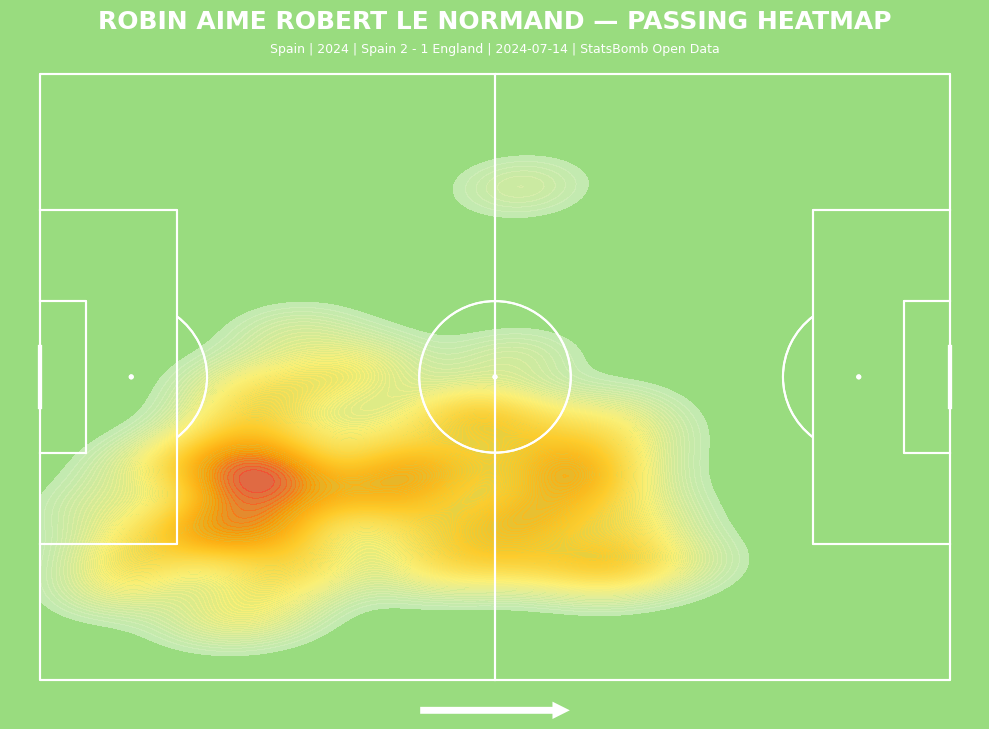

In [122]:
fig, ax = plot_pass_density_heatmap(
    passes=player_passes,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source="StatsBomb Open Data"
)

plt.show()